# US 7,557,996 B2 — projection objective construction and imaging

**Canonical embodiment:** Figure 3, Tables 3 and 3A.  
**Operating point:** $\lambda=193.368$ nm, image-side NA = 1.2, nominal 4× reduction.

This notebook follows the workflow of the objective notebooks in this folder:

1. construct the complete patent prescription;
2. evaluate the spherical/even-asphere surface equation;
3. trace rays by exact surface intersection, Snell refraction, and reflection;
4. draw the closed lens layout and folded ray path;
5. verify conjugates, magnification, clear apertures, and numerical aperture;
6. calculate geometric spots and the scalar diffraction PSF;
7. form an illustrative aerial image.

The implementation is in `patent_objective.py` so that the same tested tracer drives both this notebook and the exported figures.

## 0 · Imports and reproducibility

All prescription dimensions are millimetres. The notebook requires NumPy, SciPy, and Matplotlib.

In [1]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import patent_objective as objective

OUT = Path('outputs_us7557996')
OUT.mkdir(exist_ok=True)
print(f'{len(objective.SURFACES)} sequential surfaces')
print(f'{len(objective.physical_lenses())} unique physical lenses')
print(f'Object plane z = {objective.OBJECT_Z:.6f} mm')
print(f'Image plane  z = {objective.IMAGE_Z:.6f} mm')

48 sequential surfaces
21 unique physical lenses
Object plane z = -76.876406 mm
Image plane  z = 1423.077700 mm


## 1 · Patent prescription

A row describes the surface radius, axial distance to the next sequential surface, medium after the surface, refractive index at 193.368 nm, and clear semidiameter. Negative thicknesses after M1 describe the reflected return path. `REFL` marks mirrors M1 and M2.

The CSV includes $K$ and $C_1\ldots C_6$ in

$$z(h)=\frac{c h^2}{1+\sqrt{1-(1+K)c^2h^2}}+\sum_{j=1}^{6} C_j h^{2j+2},\qquad c=1/R.$$

In [2]:
csv_path = Path('US7557996_Fig3_Table3_prescription.csv')
objective.export_prescription_csv(csv_path)

with csv_path.open() as stream:
    rows = list(csv.DictReader(stream))

columns = ['surface', 'surface_type', 'radius_mm', 'thickness_to_next_mm',
           'material_after', 'index_193.368_nm', 'clear_semidiameter_mm', 'aspheric']
print(' | '.join(f'{name:>20}' for name in columns))
print('-' * 180)
for row in rows:
    print(' | '.join(f'{row[name]:>20}' for name in columns))

             surface |         surface_type |            radius_mm | thickness_to_next_mm |       material_after |     index_193.368_nm | clear_semidiameter_mm |             aspheric
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                   1 |           refractive |       -404.542022000 |         36.232225000 |                 SIO2 |           1.56078570 |               88.996 |                False
                   2 |           refractive |       -184.402723000 |          1.000090000 |                  AIR |           1.00000000 |               95.088 |                 True
                   3 |           refractive |        674.592973000 |         51.347982000 |                 SIO2 |           1.56078570 |              102.076 |                False
                   4 |           refractive |       -174.232362000 |        144.581202000 

## 2 · Surface mathematics and exact sequential tracer

Each ray is intersected with the full rotationally symmetric sag by Newton iteration. The local normal is obtained from the sag derivative. Refractive surfaces apply vector Snell refraction; surfaces 7 and 10 apply the vector reflection law. Every hit is checked against the patent clear semidiameter.

Surface: 23
Maximum sag (mm): 16.43938618233247
Interior slope discrepancy: 1.5085150028015804e-06


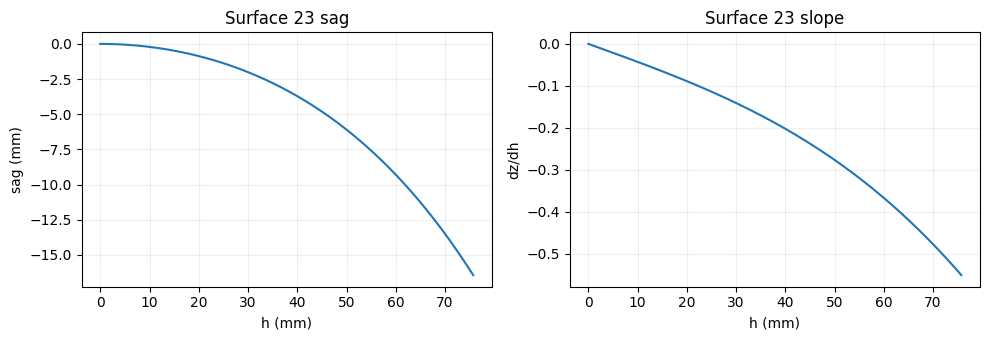

In [3]:
# Inspect a representative asphere and confirm that the analytic slope
# agrees with a centred finite difference.
surface = objective.SURFACES[22]  # surface 23
h = np.linspace(0, 0.9 * surface.semidiameter, 400)
sag, slope = objective.sag_and_slope(surface, h)
numeric_slope = np.gradient(sag, h)
print('Surface:', surface.number)
print('Maximum sag (mm):', float(np.max(np.abs(sag))))
print('Interior slope discrepancy:', float(np.max(np.abs(slope[2:-2] - numeric_slope[2:-2]))))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(h, sag); axes[0].set(xlabel='h (mm)', ylabel='sag (mm)', title='Surface 23 sag')
axes[1].plot(h, slope); axes[1].set(xlabel='h (mm)', ylabel='dz/dh', title='Surface 23 slope')
for ax in axes: ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

## 3 · Conjugate recovery and first-order validation

Table 3 does not list the object-plane separation. It is recovered from the numerical paraxial matrix by imposing $B=0$ at the tabulated image plane. This is not a fit of the optical surfaces. The resulting transverse magnification must be +0.25: both objective parts invert, producing a net upright 4× reduction.

In [4]:
print(f'Recovered object plane: z = {objective.OBJECT_Z:.9f} mm')
print(f'Numerical paraxial magnification: {objective.PARAXIAL_MAGNIFICATION:.10f}')
assert abs(objective.PARAXIAL_MAGNIFICATION - 0.25) < 2e-7

for object_y in (56.0, 62.0, 67.0):
    sy = objective.chief_slope(object_y)
    ray = objective.ray_from_object((0, object_y), (0, sy), keep_path=True)
    print(f'object y={object_y:5.1f} mm -> image y={ray["image"][1]:9.6f} mm, chief slope={sy:+.7f}')

Recovered object plane: z = -76.876406191 mm
Numerical paraxial magnification: 0.2500000135
object y= 56.0 mm -> image y=14.000000 mm, chief slope=-0.0018425


object y= 62.0 mm -> image y=15.499997 mm, chief slope=-0.0031983
object y= 67.0 mm -> image y=16.749999 mm, chief slope=-0.0048404


## 4 · Closed-form optical layout and ray trace

Unlike a surface-only prescription plot, the drawing below closes each lens with both optical faces and its rim edges. Fused silica, CaF₂, and the final high-index element are filled separately; the high-index immersion layer is shaded at the wafer end. The two thick black curves are M1 and M2.

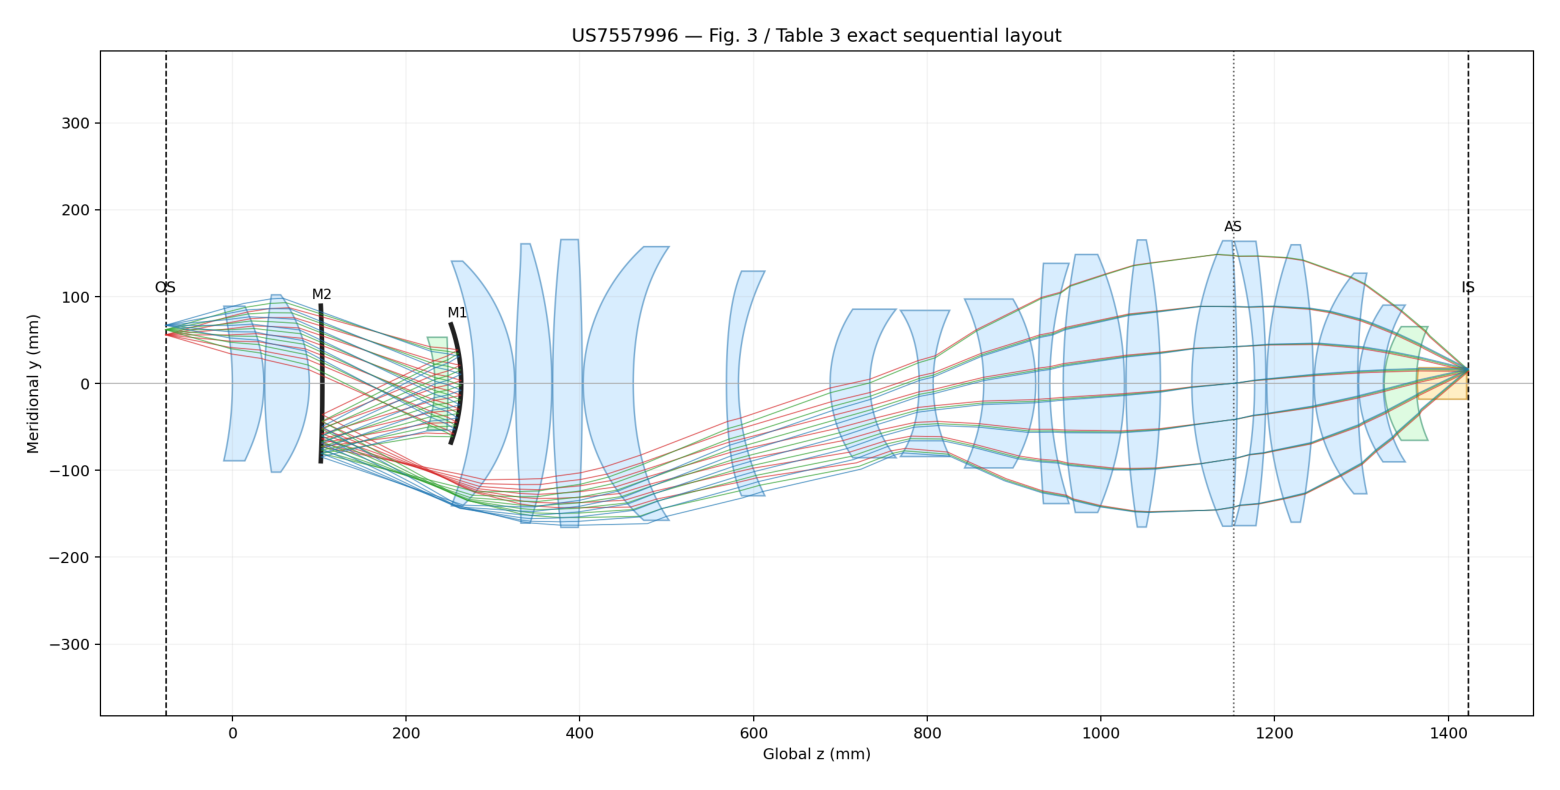

In [5]:
layout_path = OUT / 'layout_raytrace.png'
objective.plot_layout(layout_path)
image = plt.imread(layout_path)
plt.figure(figsize=(16, 8))
plt.imshow(image); plt.axis('off'); plt.tight_layout(); plt.show()

## 5 · Pupil coverage and numerical aperture

The nominal object-space sine is approximately $1.2/4=0.3$. Rays are sampled over this circular pupil and rejected only when a patent clear aperture clips them. Image-space NA is measured as $n\sqrt{d_x^2+d_y^2}$ in the final medium.

Unvignetted rays: 754
Maximum traced image-space NA: 1.197703


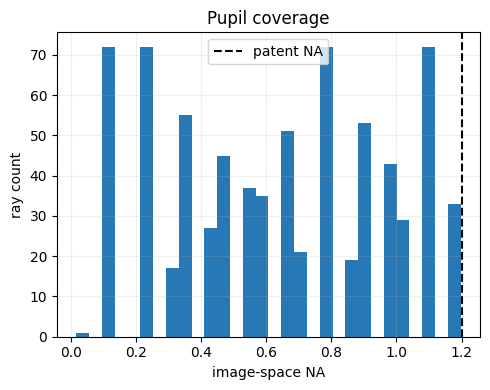

In [6]:
rays = objective.pupil_rays(object_y=62.0, radial_samples=12, azimuth_samples=72)
n_image = objective.SURFACES[-1].index
image_na = np.array([n_image * np.hypot(item[2]['direction'][0], item[2]['direction'][1]) for item in rays])
print('Unvignetted rays:', len(rays))
print(f'Maximum traced image-space NA: {image_na.max():.6f}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(image_na, bins=30, color='#2878b5')
ax.axvline(objective.NA_IMAGE, color='black', ls='--', label='patent NA')
ax.set(xlabel='image-space NA', ylabel='ray count', title='Pupil coverage')
ax.legend(); ax.grid(alpha=.2); plt.tight_layout(); plt.show()

## 6 · Geometric image quality

The spot plots use exact non-paraxial rays at three positions in the annular object field. Coordinates are recentered at the median image intercept. The outer patent boundary is $Y'=17$ mm; the final sample is kept just inside that hard clear-aperture limit.

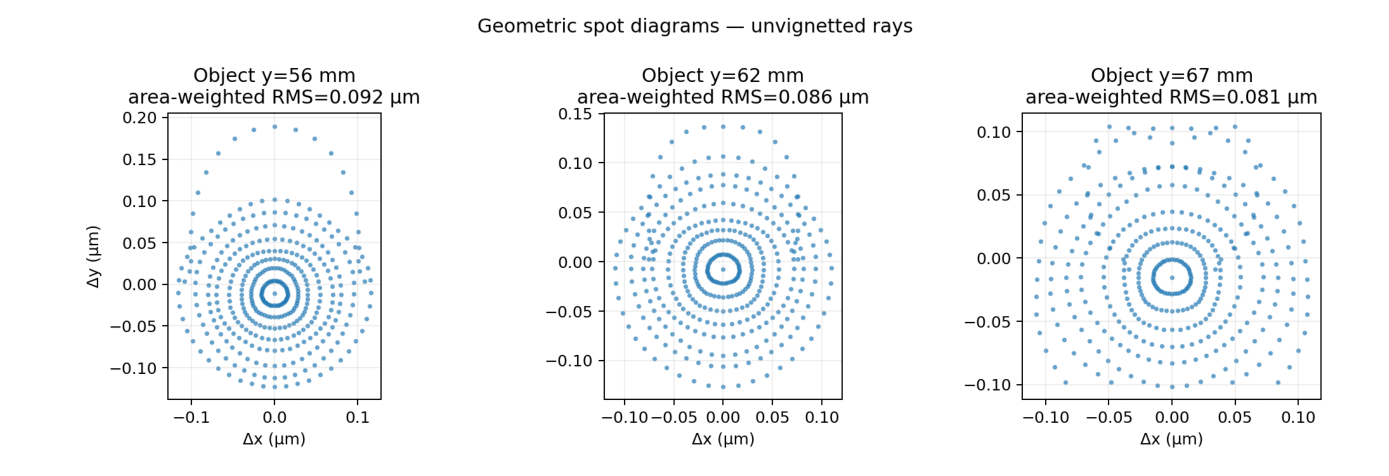

In [7]:
spots_path = OUT / 'spot_diagrams.png'
objective.plot_spots(spots_path)
plt.figure(figsize=(14, 5))
plt.imshow(plt.imread(spots_path)); plt.axis('off'); plt.tight_layout(); plt.show()

## 7 · Monochromatic aberration measurements

The following measurements are evaluated directly from exact rays over the usable circular pupil:

- area-weighted RMS sagittal, tangential, and radial spot error;
- 80% encircled-energy radius (EE80);
- centroid distortion relative to the 4× paraxial image;
- sagittal and tangential best-focus shifts;
- astigmatic separation, defined as tangential minus sagittal focus;
- tangential and sagittal transverse ray-aberration fans.

These are monochromatic measurements at 193.368 nm. Chromatic aberration cannot be reconstructed because the patent supplies refractive indices at only one wavelength.

      image y (mm) |           RMS (µm) |      best RMS (µm) |          EE80 (µm) |    distortion (µm) |    S focus Δz (mm) |    T focus Δz (mm) |           T−S (mm)
         14.000011 |        0.092218766 |        0.012736099 |         0.11107446 |        0.010783338 |     -0.00012421923 |     -0.00013583882 |      -1.161959e-05
         15.500005 |        0.086225812 |        0.014922365 |         0.10534665 |       0.0051072266 |      -0.0001156703 |     -0.00012617838 |     -1.0508084e-05
         16.750014 |        0.081181224 |        0.020834862 |         0.10324211 |        0.014383354 |     -0.00011056055 |     -0.00012247998 |     -1.1919436e-05


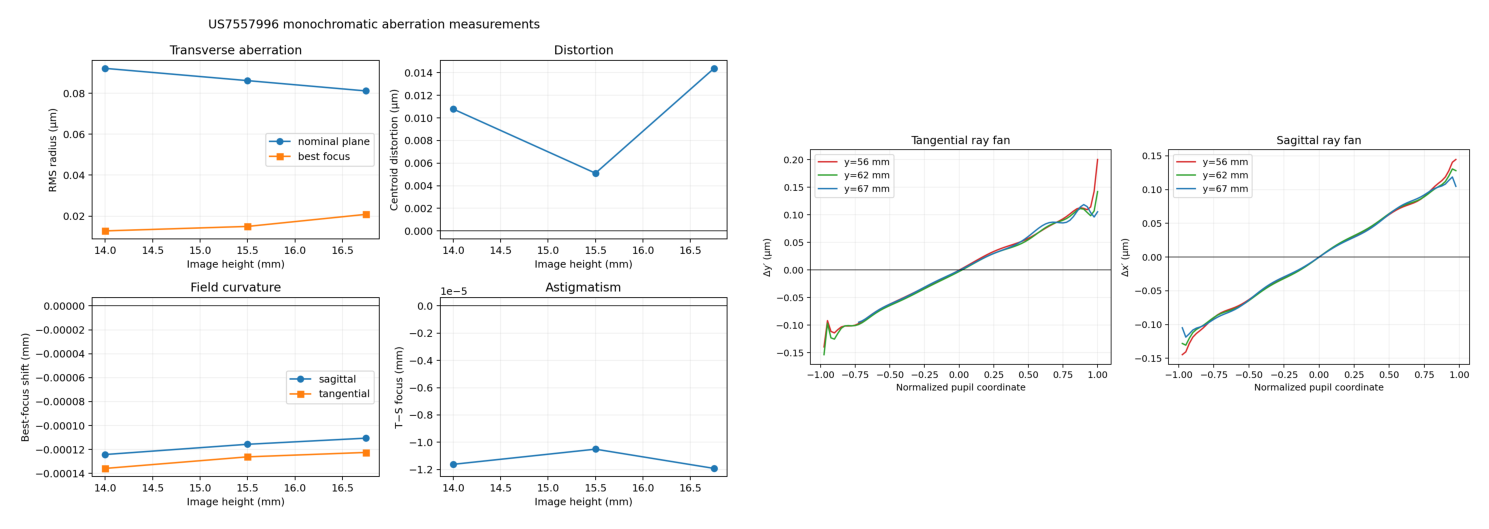

In [8]:
aberrations = objective.aberration_metrics()
aberration_csv = Path('US7557996_aberration_metrics.csv')
objective.export_aberration_csv(aberration_csv, aberrations)
objective.plot_aberrations(OUT / 'aberration_summary.png',
                           OUT / 'ray_aberration_fans.png', aberrations)

header = ('image y (mm)', 'RMS (µm)', 'best RMS (µm)', 'EE80 (µm)', 'distortion (µm)',
          'S focus Δz (mm)', 'T focus Δz (mm)', 'T−S (mm)')
print(' | '.join(f'{item:>18}' for item in header))
for row in aberrations:
    values = (row['centroid_image_height_mm'], row['rms_spot_radius_um'],
              row['best_focus_rms_spot_um'], row['ee80_radius_um'], row['distortion_um'],
              row['sagittal_focus_shift_mm'], row['tangential_focus_shift_mm'],
              row['astigmatic_separation_mm'])
    print(' | '.join(f'{value:18.8g}' for value in values))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].imshow(plt.imread(OUT / 'aberration_summary.png')); axes[0].axis('off')
axes[1].imshow(plt.imread(OUT / 'ray_aberration_fans.png')); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 8 · ANSI/OSA Zernike wavefront expansion

The monochromatic wavefront is reconstructed from the exact transverse ray aberrations using Hamilton's ray/wavefront relation

$$\nabla_{\mathbf q}W=-\mathrm{NA}\,\Delta\mathbf r',$$

where $\mathbf q$ is normalized image-space optical direction. Gradients of RMS-normalized ANSI/OSA Zernikes are fitted through radial order 6. This avoids an arbitrary phase convention through the folded catadioptric path. Coefficients are reported in nanometres RMS and waves RMS. Piston is unobservable from ray slopes; tilt and defocus are explicitly removable.

RMS excluding tilt: 21.0048 nm
RMS after tilt/defocus removal: 0.5089 nm
Gradient-fit residual: 0.004287 µm
ANSI  1  (1,-1)  Y tilt                               +4.018018 nm RMS
ANSI  2  (1,+1)  X tilt                               -0.000000 nm RMS
ANSI  3  (2,-2)  Oblique astigmatism                  +0.000000 nm RMS
ANSI  4  (2,+0)  Defocus                             -20.998673 nm RMS
ANSI  5  (2,+2)  Vertical astigmatism                 -0.088437 nm RMS
ANSI  6  (3,-3)  Oblique trefoil                      -0.046688 nm RMS
ANSI  7  (3,-1)  Y coma                               +0.176357 nm RMS
ANSI  8  (3,+1)  X coma                               -0.000000 nm RMS
ANSI  9  (3,+3)  Vertical trefoil                     +0.000000 nm RMS
ANSI 10  (4,-4)  Oblique quadrafoil                   -0.000000 nm RMS
ANSI 11  (4,-2)  Secondary oblique astigmatism        +0.000000 nm RMS
ANSI 12  (4,+0)  Primary spherical                    -0.053739 nm RMS
ANSI 13  (4,+2)  Secondary vertical asti

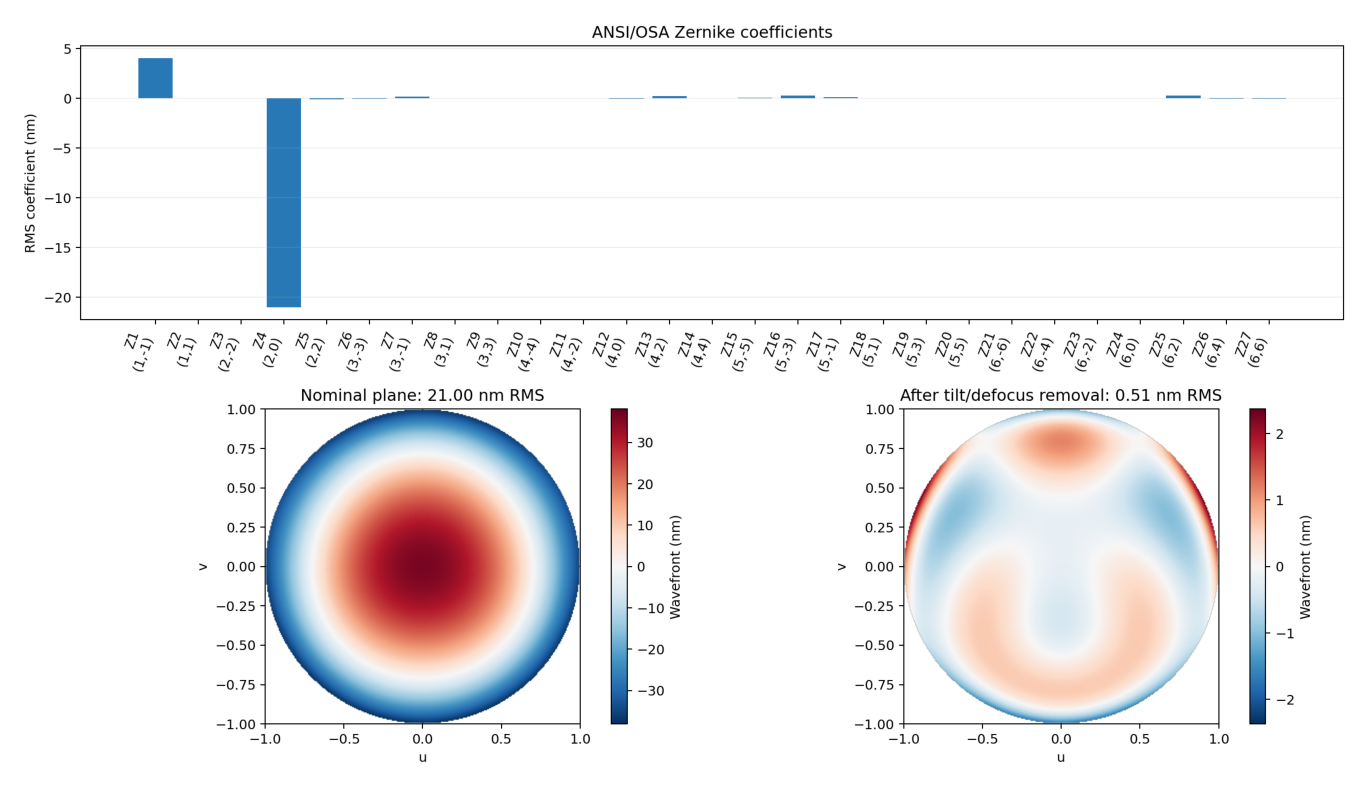

In [9]:
zfit = objective.zernike_expansion(object_y=62.0, max_order=6)
objective.export_zernike_csv(Path('US7557996_zernike_coefficients.csv'), zfit)
objective.plot_zernikes(OUT / 'zernike_wavefront.png', zfit)

print(f"RMS excluding tilt: {zfit['rms_no_tilt_nm']:.4f} nm")
print(f"RMS after tilt/defocus removal: {zfit['rms_refocused_nm']:.4f} nm")
print(f"Gradient-fit residual: {zfit['gradient_fit_residual_um']:.6f} µm")
for row in zfit['records']:
    print(f"ANSI {row['ansi_index']:2d}  ({row['radial_order_n']},{row['azimuthal_frequency_m']:+d})  "
          f"{row['name']:<34s} {row['coefficient_nm_rms']:+11.6f} nm RMS")

plt.figure(figsize=(14, 8))
plt.imshow(plt.imread(OUT / 'zernike_wavefront.png'))
plt.axis('off'); plt.tight_layout(); plt.show()

## 9 · Partially coherent Abbe aerial image

This follows the companion notebooks: the fitted best-focus Zernike wavefront becomes pupil phase, a synthetic wafer-scale mask contains line/space arrays, elbows, an isolated line, and contacts, and a conventional circular source with $\sigma=0.7$ is integrated by the Abbe method. The output shows the mask, aerial intensity, and a thresholded resist image.

$$r_{\rm Airy}=0.61\lambda/\mathrm{NA}=98.3\ \mathrm{nm}.$$

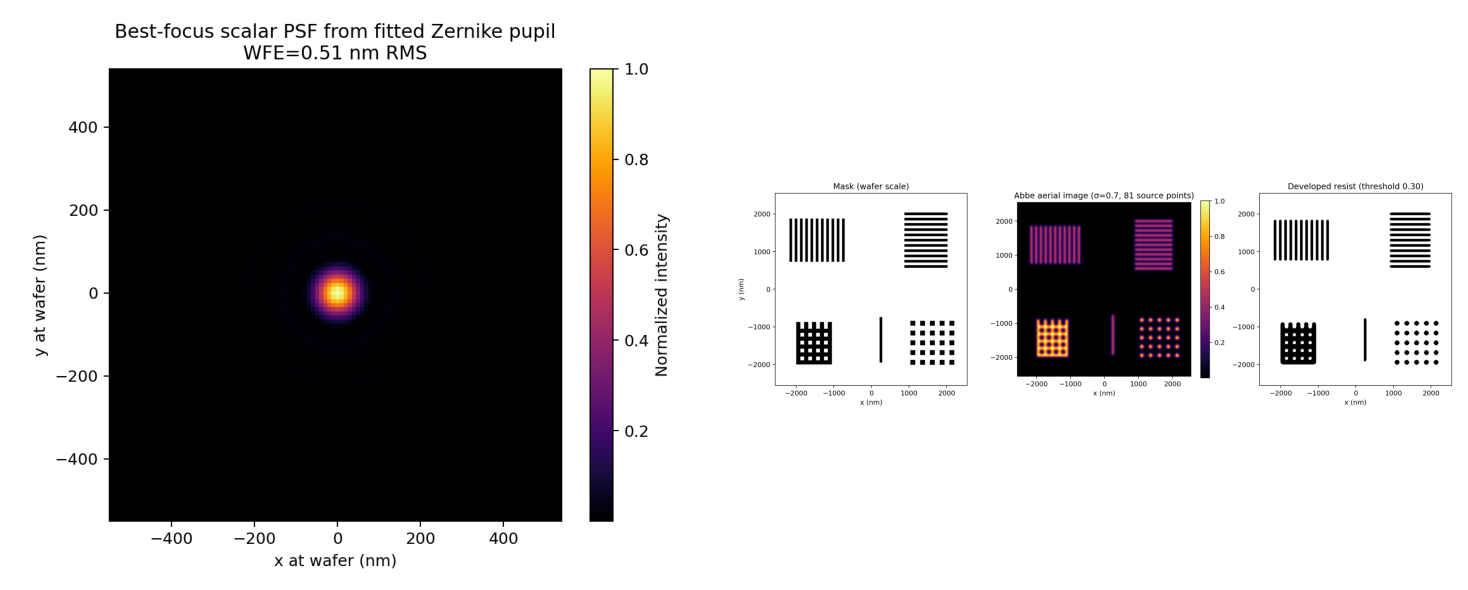

In [10]:
psf_path = OUT / 'scalar_psf.png'
aerial_path = OUT / 'aerial_image.png'
objective.scalar_imaging(psf_path, aerial_path, zfit)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(plt.imread(psf_path)); axes[0].axis('off')
axes[1].imshow(plt.imread(aerial_path)); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 10 · Numerical summary and limitations

- The complete 48-surface patent prescription, including all 12 even aspheres, is used without refitting.
- The recovered paraxial magnification is +0.25 to numerical precision.
- The traced marginal rays reach image-space NA ≈ 1.2.
- The central annular-field geometric RMS radius is about 0.073 µm.
- The aberration table reports distortion, EE80, sagittal/tangential focus, and astigmatic separation across the annular field.
- The scalar Airy radius is 0.0983 µm.

A manufacturing-grade lithography prediction would additionally require polarization-dependent coatings, vector diffraction, the actual illumination pupil, mask topography, immersion-medium dispersion, tolerances, and a resist model.

In [11]:
objective.write_report(OUT / 'REPORT.md')
print((OUT / 'REPORT.md').read_text())

# US7557996 objective model

Canonical embodiment: Figure 3 / Tables 3 and 3A.

- Wavelength: 193.368 nm
- Image-side NA: 1.2
- Nominal reduction: 4×
- Sequential surfaces: 48 (including 2 mirrors)
- Unique physical lenses: 21
- Recovered object plane z: -76.876406 mm
- Numerical paraxial magnification: 0.25000001
- Image plane z: 1423.077700 mm
- Centre-field retained pupil rays: 408
- Centre-field geometric RMS radius: 0.0862 µm
- Ideal scalar Airy radius: 98.30 nm

## Monochromatic aberrations

| Image height (mm) | RMS spot (µm) | Best-focus RMS (µm) | EE80 radius (µm) | Distortion (µm) | Sagittal focus Δz (mm) | Tangential focus Δz (mm) | T−S astigmatism (mm) |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 14.000011 | 0.0922 | 0.0127 | 0.1111 | +0.010783 | -1.242192e-04 | -1.358388e-04 | -1.161959e-05 |
| 15.500005 | 0.0862 | 0.0149 | 0.1053 | +0.005107 | -1.156703e-04 | -1.261784e-04 | -1.050808e-05 |
| 16.750014 | 0.0812 | 0.0208 | 0.1032 | +0.014383 | -1.105605e-04 | -1.224800e-0